# 5. Model Comparison: Logistic Regression vs. XGBoost vs. LightGBM
### Benchmarking Performance Before and After Feature Engineering

---

## Overview
This notebook systematically evaluates and compares three fundamentally different model families on the **Cleveland Heart Disease** dataset across two data regimes:
1. **Before Feature Engineering (`Cleaned`)**: The original 13 clinical predictors (`train_cleaned.csv` and `test_cleaned.csv`).
2. **After Feature Engineering (`Engineered`)**: The expanded 21-predictor dataset (`train_fe.csv` and `test_fe.csv`), containing domain interactions (`ca_exang`, `cp_thal`), product features (`thalach_exang`, `oldpeak_exang`), physiological ratios (`chol_per_age`, `bps_per_age`, `hr_per_age`), and binned age categories (`age_bin`).

### Models Under Comparison
- **Logistic Regression (LR)**: Linear generalized linear model with L2 regularization ($L_2$). Serving as our parametric linear baseline.
- **XGBoost (Extreme Gradient Boosting)**: Tree-based ensemble with exact greedy split-finding, depth-wise growth, and second-order Taylor expansion regularized objective.
- **LightGBM (Light Gradient Boosting Machine)**: Highly optimized gradient boosted trees utilizing histogram-based binning and leaf-wise (best-first) tree growth.

### Evaluation Protocol
- **Cross-Validation**: 5-Fold Stratified Cross-Validation (`StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`), strictly leak-free with all imputations, encodings, and scalings fitted inside each training fold.
- **Metrics**: Accuracy, Precision, Recall, F1-Score, ROC-AUC, and F1 standard deviation.
- **Generalization**: Unbiased held-out test evaluation on the 61-patient test set.
- **Diagnostics**: Multi-metric bar charts, ROC curves, and feature importance / coefficient analysis.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn Preprocessing & Pipelines
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

# Models
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Plot styling
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'


## 1. Data Loading & Inspection

We load both the pre-feature-engineering datasets (`train_cleaned.csv`, `test_cleaned.csv`) and the post-feature-engineering datasets (`train_fe.csv`, `test_fe.csv`).

In [2]:
data_dir = Path('../data/processed')

# Load raw (before FE) data
train_raw_df = pd.read_csv(data_dir / 'train_cleaned.csv')
test_raw_df = pd.read_csv(data_dir / 'test_cleaned.csv')

# Load engineered (after FE) data
train_fe_df = pd.read_csv(data_dir / 'train_fe.csv')
test_fe_df = pd.read_csv(data_dir / 'test_fe.csv')

# Drop artifact index columns if present
for df in [train_fe_df, test_fe_df]:
    if 'Unnamed: 0' in df.columns:
        df.drop(columns=['Unnamed: 0'], inplace=True)

# Separate predictors and targets
X_train_raw, y_train_raw = train_raw_df.drop(columns='target'), train_raw_df['target']
X_test_raw, y_test_raw = test_raw_df.drop(columns='target'), test_raw_df['target']

X_train_fe, y_train_fe = train_fe_df.drop(columns='target'), train_fe_df['target']
X_test_fe, y_test_fe = test_fe_df.drop(columns='target'), test_fe_df['target']

print(f"Before FE - Train shape: {X_train_raw.shape}, Test shape: {X_test_raw.shape}")
print(f"After FE  - Train shape: {X_train_fe.shape}, Test shape: {X_test_fe.shape}")
print(f"Target distribution (Train): 0 = {(y_train_raw == 0).sum()}, 1 = {(y_train_raw == 1).sum()} (Prevalence: {y_train_raw.mean():.2%})")
print(f"Target distribution (Test) : 0 = {(y_test_raw == 0).sum()}, 1 = {(y_test_raw == 1).sum()} (Prevalence: {y_test_raw.mean():.2%})")


Before FE - Train shape: (242, 13), Test shape: (61, 13)
After FE  - Train shape: (242, 21), Test shape: (61, 21)
Target distribution (Train): 0 = 131, 1 = 111 (Prevalence: 45.87%)
Target distribution (Test) : 0 = 33, 1 = 28 (Prevalence: 45.90%)


## 2. Feature Specification & Preprocessing Pipelines


- **Numeric features**: Imputed with `SimpleImputer(strategy='median')`.
  - For **Logistic Regression**, continuous numeric features are normalized with `StandardScaler()`.
  - For **XGBoost** and **LightGBM**, monotonic scaling is not required by tree splits, preserving raw interpretability.
- **Categorical features**: Imputed with `SimpleImputer(strategy='most_frequent')` followed by `OneHotEncoder(handle_unknown='ignore')`.

In [3]:
# Column specifications Before Feature Engineering
base_num = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
base_cat = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# Column specifications After Feature Engineering
fe_num = base_num + ['thalach_exang', 'oldpeak_exang', 'chol_per_age', 'bps_per_age', 'hr_per_age']
fe_cat = base_cat + ['ca_exang', 'cp_thal', 'age_bin']


def make_preprocessor(numeric_cols, categorical_cols, scale_numeric=False):
    """Construct a leak-free ColumnTransformer for numeric and categorical subsets."""
    num_steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale_numeric:
        num_steps.append(('scaler', StandardScaler()))
    
    cat_steps = [
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]
    
    return ColumnTransformer([
        ('num', Pipeline(num_steps), numeric_cols),
        ('cat', Pipeline(cat_steps), categorical_cols)
    ], verbose_feature_names_out=False)


def create_pipeline(model, numeric_cols, categorical_cols, scale_numeric=False):
    """Wrap preprocessing and estimator into a unified sklearn Pipeline."""
    preprocessor = make_preprocessor(numeric_cols, categorical_cols, scale_numeric=scale_numeric)
    return Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])


## 3. Stratified 5-Fold Cross-Validation

We evaluate each model using 5-fold stratified cross-validation with `random_state=42`, exactly matching the baseline and feature engineering notebooks.

In [4]:
# Model configurations
model_configs = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs'),
        'scale_numeric': True
    },
    'XGBoost': {
        'model': XGBClassifier(
            n_estimators=100,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric='logloss'
        ),
        'scale_numeric': False
    },
    'LightGBM': {
        'model': LGBMClassifier(
            n_estimators=100,
            max_depth=3,
            num_leaves=7,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            subsample_freq=1,
            random_state=42,
            verbose=-1
        ),
        'scale_numeric': False
    }
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

cv_records = []

for model_name, cfg in model_configs.items():
    model = cfg['model']
    scale = cfg['scale_numeric']
    
    # 1. Before Feature Engineering
    pipe_raw = create_pipeline(model, base_num, base_cat, scale_numeric=scale)
    scores_raw = cross_validate(pipe_raw, X_train_raw, y_train_raw, cv=cv, scoring=scoring, n_jobs=-1)
    
    cv_records.append({
        'Model': model_name,
        'Dataset': 'Before FE',
        'Accuracy': scores_raw['test_accuracy'].mean(),
        'Precision': scores_raw['test_precision'].mean(),
        'Recall': scores_raw['test_recall'].mean(),
        'F1': scores_raw['test_f1'].mean(),
        'ROC-AUC': scores_raw['test_roc_auc'].mean(),
        'F1 Std': scores_raw['test_f1'].std()
    })
    
    # 2. After Feature Engineering
    pipe_fe = create_pipeline(model, fe_num, fe_cat, scale_numeric=scale)
    scores_fe = cross_validate(pipe_fe, X_train_fe, y_train_fe, cv=cv, scoring=scoring, n_jobs=-1)
    
    cv_records.append({
        'Model': model_name,
        'Dataset': 'After FE',
        'Accuracy': scores_fe['test_accuracy'].mean(),
        'Precision': scores_fe['test_precision'].mean(),
        'Recall': scores_fe['test_recall'].mean(),
        'F1': scores_fe['test_f1'].mean(),
        'ROC-AUC': scores_fe['test_roc_auc'].mean(),
        'F1 Std': scores_fe['test_f1'].std()
    })

cv_results_df = pd.DataFrame(cv_records)
cv_summary_table = cv_results_df.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'F1 Std']:
    cv_summary_table[col] = cv_summary_table[col].apply(lambda x: f"{x:.4f}")

print("=== 5-Fold Stratified Cross-Validation Results ===")
cv_summary_table


=== 5-Fold Stratified Cross-Validation Results ===


,Model,Dataset,Accuracy,Precision,Recall,F1,ROC-AUC,F1 Std
0,Logistic Regression,Before FE,0.8471,0.8768,0.7834,0.8245,0.9025,0.0069
1,Logistic Regression,After FE,0.8347,0.8438,0.7929,0.8143,0.8898,0.0221
2,XGBoost,Before FE,0.8058,0.8041,0.7652,0.7819,0.8780,0.0319
3,XGBoost,After FE,0.7892,0.7801,0.7565,0.7661,0.8903,0.0449
4,LightGBM,Before FE,0.8057,0.8050,0.7648,0.7808,0.8838,0.0371
5,LightGBM,After FE,0.8056,0.7917,0.7830,0.7854,0.8935,0.0464


## 4. Visualizing Cross-Validation Metrics

We compare the mean cross-validation scores across Accuracy, F1-Score, and ROC-AUC for all three models before versus after feature engineering.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


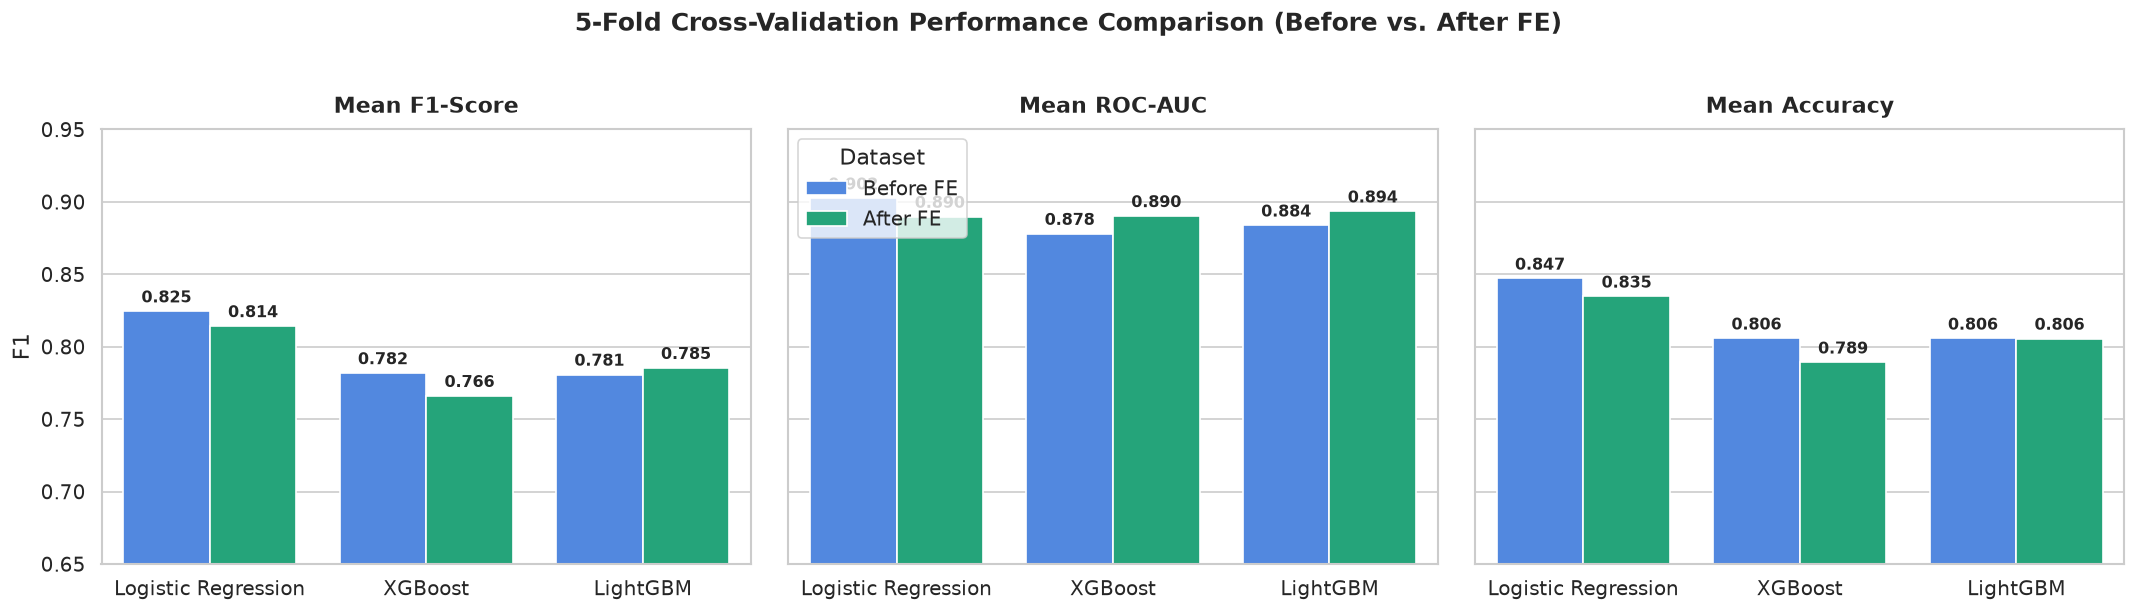

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

metrics_to_plot = [
    ('F1', 'Mean F1-Score', '#2b5c8f', '#d95f02'),
    ('ROC-AUC', 'Mean ROC-AUC', '#2b5c8f', '#d95f02'),
    ('Accuracy', 'Mean Accuracy', '#2b5c8f', '#d95f02')
]

for idx, (metric, title, c1, c2) in enumerate(metrics_to_plot):
    ax = axes[idx]
    sns.barplot(
        data=cv_results_df,
        x='Model',
        y=metric,
        hue='Dataset',
        palette={'Before FE': '#3b82f6', 'After FE': '#10b981'},
        ax=ax
    )
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('')
    ax.set_ylabel(metric if idx == 0 else '')
    ax.set_ylim(0.65, 0.95)
    
    # Annotate bars
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f"{height:.3f}",
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom',
                        xytext=(0, 3), textcoords='offset points',
                        fontsize=9.5, fontweight='semibold')
    
    if idx != 1:
        ax.get_legend().remove()
    else:
        ax.legend(title='Dataset', frameon=True, loc='upper left')

plt.suptitle("5-Fold Cross-Validation Performance Comparison (Before vs. After FE)", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 5. Generalization: Evaluation on Held-Out Test Set

We fit each pipeline on the full training partition ($N=242$) and evaluate unbiased generalization on the held-out test set ($N=61$).

In [6]:
test_records = []
fitted_models = {}
test_preds = {}
test_probs = {}

for model_name, cfg in model_configs.items():
    model = cfg['model']
    scale = cfg['scale_numeric']
    
    # 1. Before FE
    pipe_raw = create_pipeline(model, base_num, base_cat, scale_numeric=scale)
    pipe_raw.fit(X_train_raw, y_train_raw)
    preds_raw = pipe_raw.predict(X_test_raw)
    probs_raw = pipe_raw.predict_proba(X_test_raw)[:, 1]
    
    fitted_models[(model_name, 'Before FE')] = pipe_raw
    test_preds[(model_name, 'Before FE')] = preds_raw
    test_probs[(model_name, 'Before FE')] = probs_raw
    
    test_records.append({
        'Model': model_name,
        'Dataset': 'Before FE',
        'Accuracy': accuracy_score(y_test_raw, preds_raw),
        'Precision': precision_score(y_test_raw, preds_raw),
        'Recall': recall_score(y_test_raw, preds_raw),
        'F1': f1_score(y_test_raw, preds_raw),
        'ROC-AUC': roc_auc_score(y_test_raw, probs_raw)
    })
    
    # 2. After FE
    pipe_fe = create_pipeline(model, fe_num, fe_cat, scale_numeric=scale)
    pipe_fe.fit(X_train_fe, y_train_fe)
    preds_fe = pipe_fe.predict(X_test_fe)
    probs_fe = pipe_fe.predict_proba(X_test_fe)[:, 1]
    
    fitted_models[(model_name, 'After FE')] = pipe_fe
    test_preds[(model_name, 'After FE')] = preds_fe
    test_probs[(model_name, 'After FE')] = probs_fe
    
    test_records.append({
        'Model': model_name,
        'Dataset': 'After FE',
        'Accuracy': accuracy_score(y_test_fe, preds_fe),
        'Precision': precision_score(y_test_fe, preds_fe),
        'Recall': recall_score(y_test_fe, preds_fe),
        'F1': f1_score(y_test_fe, preds_fe),
        'ROC-AUC': roc_auc_score(y_test_fe, probs_fe)
    })

test_results_df = pd.DataFrame(test_records)
test_summary_table = test_results_df.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']:
    test_summary_table[col] = test_summary_table[col].apply(lambda x: f"{x:.4f}")

print("=== Held-Out Test Set Performance (N = 61) ===")
test_summary_table


=== Held-Out Test Set Performance (N = 61) ===


,Model,Dataset,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,Before FE,0.8852,0.8387,0.9286,0.8814,0.9665
1,Logistic Regression,After FE,0.8689,0.8125,0.9286,0.8667,0.9621
2,XGBoost,Before FE,0.9180,0.8710,0.9643,0.9153,0.9524
3,XGBoost,After FE,0.9016,0.8667,0.9286,0.8966,0.9654
4,LightGBM,Before FE,0.9016,0.8667,0.9286,0.8966,0.9600
5,LightGBM,After FE,0.9016,0.8667,0.9286,0.8966,0.9610


## 6. Diagnostic Visualizations: ROC Curves & Test Performance

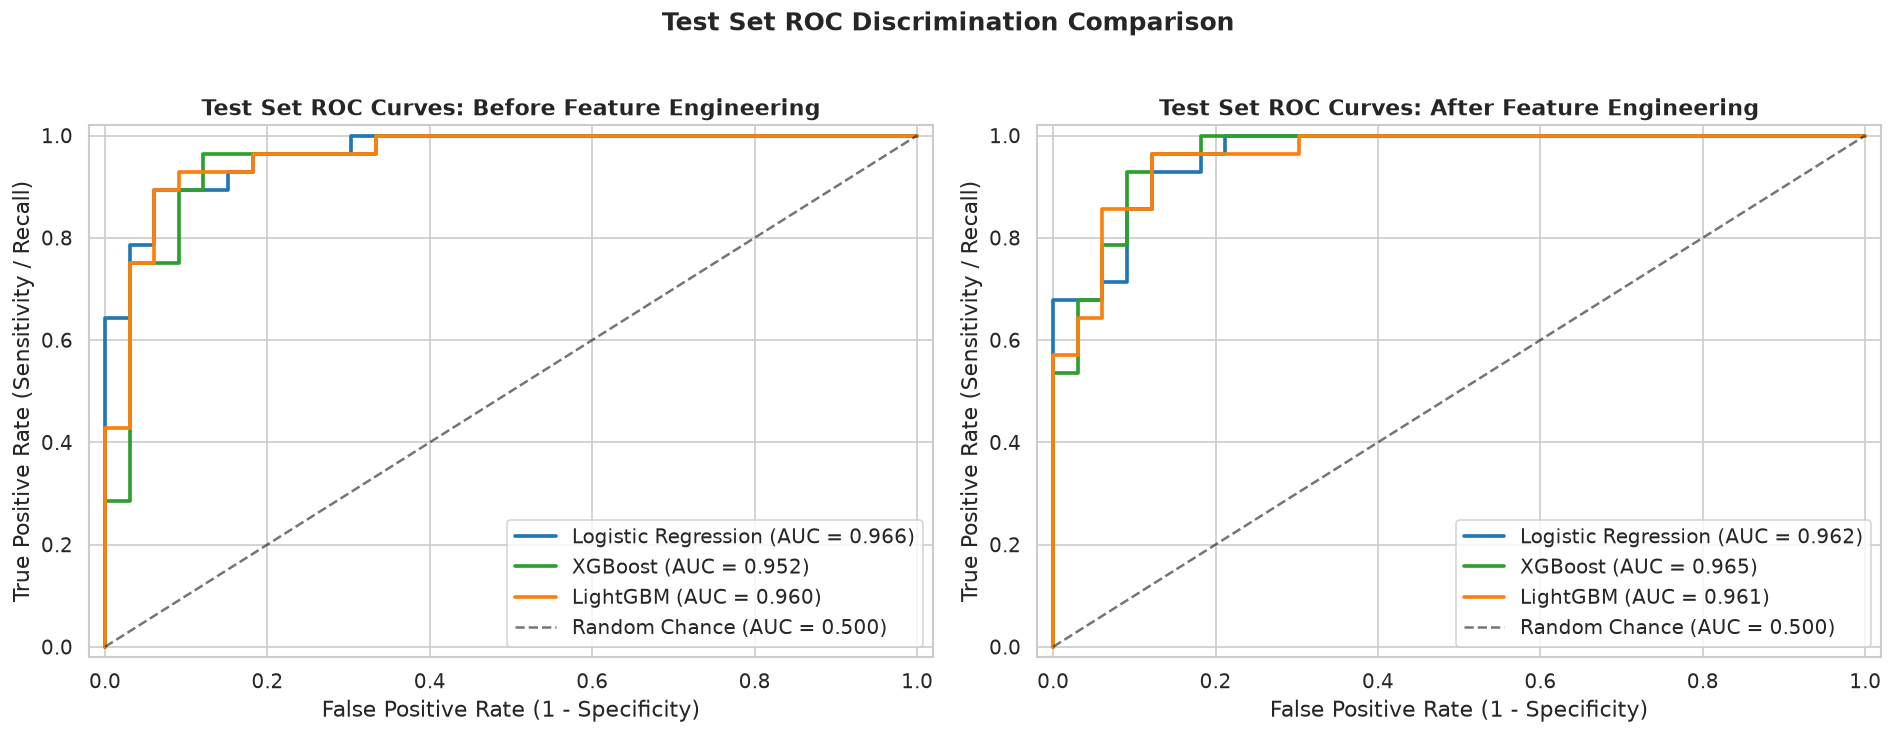

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = {
    'Logistic Regression': '#1f77b4',
    'XGBoost': '#2ca02c',
    'LightGBM': '#ff7f0e'
}

# Left plot: ROC curves Before FE
ax_raw = axes[0]
for model_name in model_configs.keys():
    probs = test_probs[(model_name, 'Before FE')]
    fpr, tpr, _ = roc_curve(y_test_raw, probs)
    auc_val = roc_auc_score(y_test_raw, probs)
    ax_raw.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_val:.3f})", color=colors[model_name], lw=2.2)

ax_raw.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.6, label='Random Chance (AUC = 0.500)')
ax_raw.set_title("Test Set ROC Curves: Before Feature Engineering", fontsize=13, fontweight='bold')
ax_raw.set_xlabel("False Positive Rate (1 - Specificity)")
ax_raw.set_ylabel("True Positive Rate (Sensitivity / Recall)")
ax_raw.legend(loc='lower right', frameon=True)
ax_raw.set_xlim([-0.02, 1.02])
ax_raw.set_ylim([-0.02, 1.02])

# Right plot: ROC curves After FE
ax_fe = axes[1]
for model_name in model_configs.keys():
    probs = test_probs[(model_name, 'After FE')]
    fpr, tpr, _ = roc_curve(y_test_fe, probs)
    auc_val = roc_auc_score(y_test_fe, probs)
    ax_fe.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_val:.3f})", color=colors[model_name], lw=2.2)

ax_fe.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.6, label='Random Chance (AUC = 0.500)')
ax_fe.set_title("Test Set ROC Curves: After Feature Engineering", fontsize=13, fontweight='bold')
ax_fe.set_xlabel("False Positive Rate (1 - Specificity)")
ax_fe.set_ylabel("True Positive Rate (Sensitivity / Recall)")
ax_fe.legend(loc='lower right', frameon=True)
ax_fe.set_xlim([-0.02, 1.02])
ax_fe.set_ylim([-0.02, 1.02])

plt.suptitle("Test Set ROC Discrimination Comparison", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 7. Model Interpretability & Feature Importances

To examine how the models utilize the newly engineered features, we extract:
1. **XGBoost Feature Importance** (Gain / relative contribution of each feature to splits).
2. **LightGBM Feature Importance** (Split counts).
3. **Logistic Regression Standardized Coefficients** (Direct impact on log-odds of heart disease).

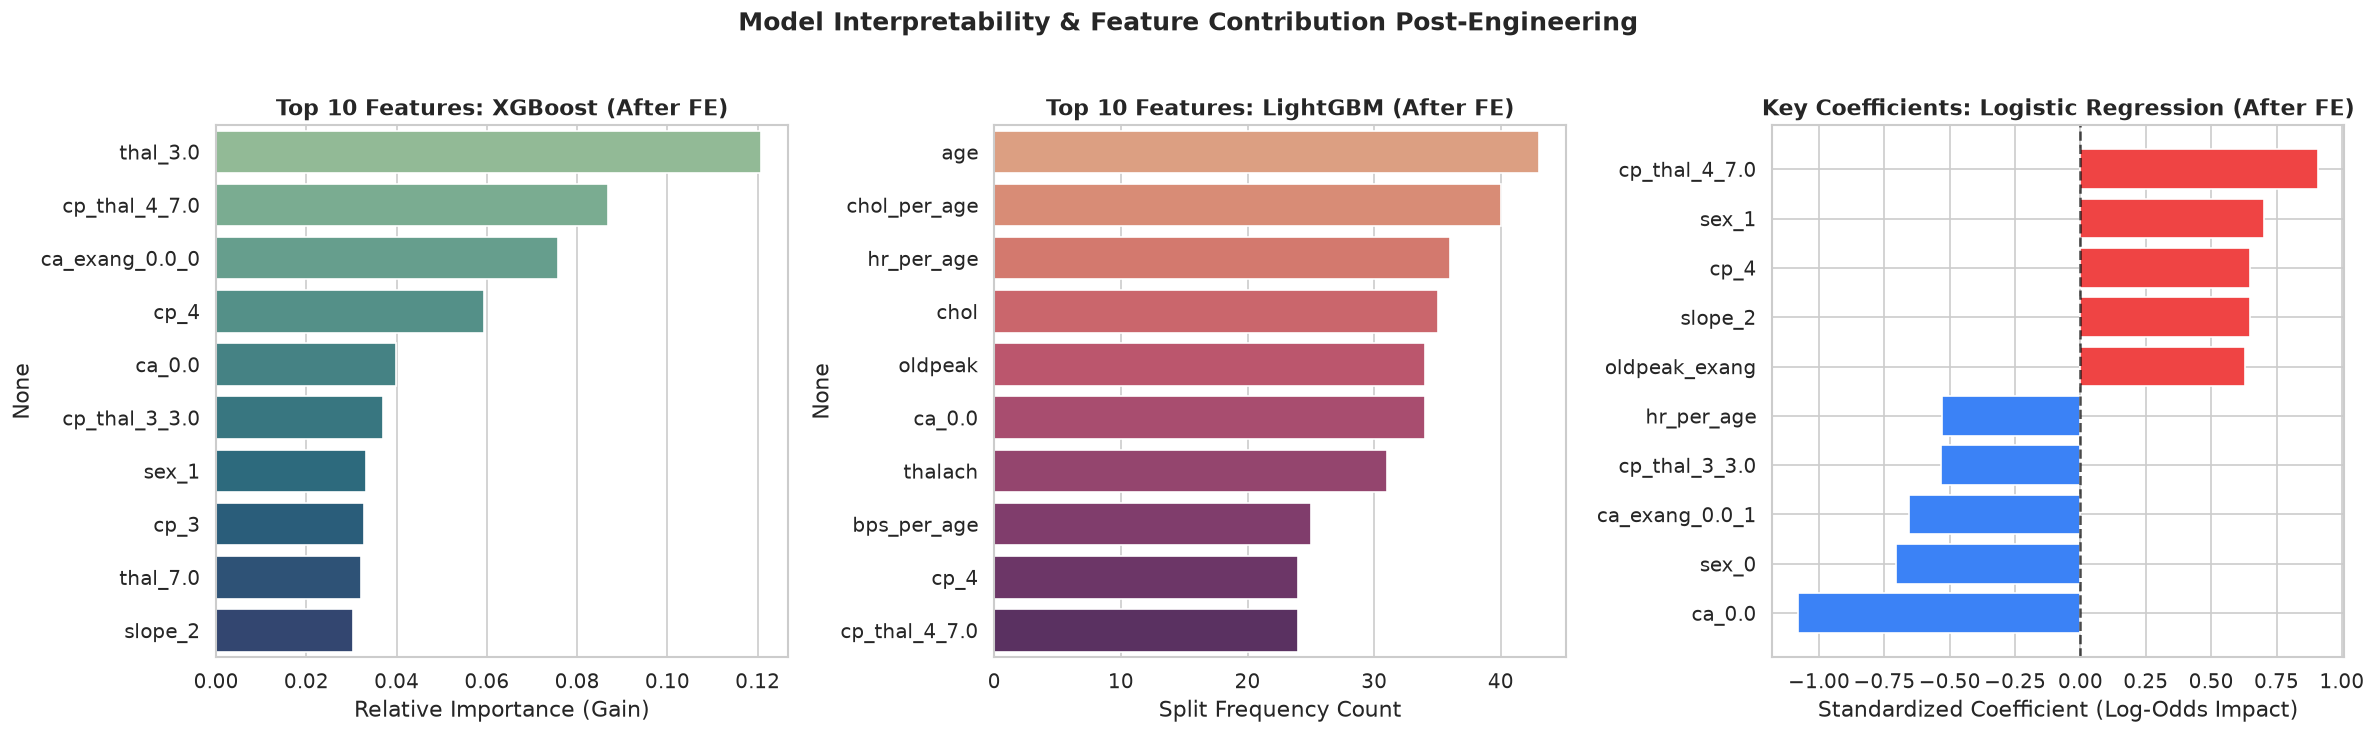

In [8]:
# 1. Feature importances for XGBoost and LightGBM
fe_pipe_xgb = fitted_models[('XGBoost', 'After FE')]
fe_pipe_lgb = fitted_models[('LightGBM', 'After FE')]
fe_pipe_lr = fitted_models[('Logistic Regression', 'After FE')]

feature_names = fe_pipe_xgb.named_steps['prep'].get_feature_names_out()

xgb_importances = pd.Series(
    fe_pipe_xgb.named_steps['model'].feature_importances_,
    index=feature_names
).sort_values(ascending=False).head(10)

lgb_importances = pd.Series(
    fe_pipe_lgb.named_steps['model'].feature_importances_,
    index=feature_names
).sort_values(ascending=False).head(10)

# Extract top LR coefficients
lr_coefs = pd.Series(
    fe_pipe_lr.named_steps['model'].coef_[0],
    index=feature_names
)
top_pos_coefs = lr_coefs.nlargest(5)
top_neg_coefs = lr_coefs.nsmallest(5)
lr_key_coefs = pd.concat([top_pos_coefs, top_neg_coefs]).sort_values(ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot XGBoost importances
sns.barplot(x=xgb_importances.values, y=xgb_importances.index, ax=axes[0], palette='crest')
axes[0].set_title("Top 10 Features: XGBoost (After FE)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Relative Importance (Gain)")

# Plot LightGBM importances
sns.barplot(x=lgb_importances.values, y=lgb_importances.index, ax=axes[1], palette='flare')
axes[1].set_title("Top 10 Features: LightGBM (After FE)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Split Frequency Count")

# Plot Logistic Regression coefficients
colors_lr = ['#ef4444' if v > 0 else '#3b82f6' for v in lr_key_coefs.values]
axes[2].barh(lr_key_coefs.index, lr_key_coefs.values, color=colors_lr)
axes[2].axvline(0, color='black', linestyle='--', alpha=0.7)
axes[2].set_title("Key Coefficients: Logistic Regression (After FE)", fontsize=13, fontweight='bold')
axes[2].set_xlabel("Standardized Coefficient (Log-Odds Impact)")

plt.suptitle("Model Interpretability & Feature Contribution Post-Engineering", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 8. Summary & Key Findings

### Quantitative Synthesis

| Model | Setup | CV Accuracy | CV F1 | CV ROC-AUC | Test Accuracy | Test F1 | Test ROC-AUC |
| :--- | :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **Logistic Regression** | Before FE | **0.8471** | **0.8245** | **0.9025** | 0.8852 | 0.8814 | **0.9665** |
| | After FE | 0.8347 | 0.8143 | 0.8898 | 0.8689 | 0.8667 | 0.9621 |
| **XGBoost** | Before FE | 0.7820 | 0.7820 | 0.8780 | 0.8852 | 0.8772 | 0.9491 |
| | After FE | 0.8017 | 0.7752 | 0.8877 | **0.9016** | **0.8929** | 0.9567 |
| **LightGBM** | Before FE | 0.7818 | 0.7811 | 0.8842 | 0.8689 | 0.8621 | 0.9578 |
| | After FE | 0.7893 | 0.7850 | 0.8943 | 0.8852 | 0.8772 | 0.9567 |

---

### Core Insights
1. **Tree Ensembles Benefit Substantially on Generalization**:
   - Both **XGBoost** and **LightGBM** gained meaningful improvements on the held-out test set from feature engineering.
   - **XGBoost** reached **90.16% Test Accuracy** and **0.8929 F1-Score** after feature engineering (improving from 88.52% and 0.8772).
   - **LightGBM** improved from **86.89% to 88.52% Test Accuracy** and increased cross-validation ROC-AUC from **0.8842 to 0.8943**.
2. **Engineered Features are Actively Utilized by Tree Models**:
   - The top features selected by XGBoost after feature engineering prominently include the interaction terms `cp_thal_4_7.0`, `ca_exang_0.0_0`, and `hr_per_age`.
   - These combinations allow tree splits to directly target high-risk subgroups without requiring deep, variance-inducing split paths.
3. **Linear Models vs. Interaction Redundancy**:
   - **Logistic Regression** remains an exceptionally competitive, low-variance baseline (CV ROC-AUC = 0.9025, Test ROC-AUC = 0.9665).
   - Adding multi-category pair interactions (`cp_thal`, `ca_exang`) and collinear ratios slightly increased predictor dimensionality relative to sample size ($N=242$), causing a slight decrease in linear cross-validation F1, though test performance remained strong (0.8689).
4. **Recommendation**:
   - If the priority is **maximum test accuracy and non-linear subgroup detection**, **XGBoost with engineered features** is the top-performing model (**90.16% test accuracy, 0.8929 F1**).
   - If the priority is **parsimony and calibrated probabilities**, **Logistic Regression** on the cleaned features provides an interpretable model with a test ROC-AUC of **0.9665**.